### Gitmore v1
##### Gitmore is the NNmodel which learns about Git commits and try to generate more of them
this version of Gitmore is only build on PyTorch Autograd under the architecture of ANN and MLP + Embeddings

In [2]:
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
commits = open('commits.txt', 'r',encoding="utf-16").read().splitlines()

In [5]:
commits = commits[:10000]
print("\n".join(commits[:5]))

Fix a stale link to the `math.integer.isqrt()` correctness proof (#154685)
Add the free-threaded Windows build output dirs to `.gitignore` (#154641)
gh-154199: Soft-deprecate `ctypes.util.find_msvcrt` (GH-154553)
gh-150621: avoid quadratic bytes slicing in `asyncio.protocols._feed_data_to_buffered_proto` (#150622)
gh-154493: Add the UCD license to `Doc/license.rst` (#154651)


In [6]:
print(f"longest commit length = {max([len(c) for c in commits])}")
print(f"shortest commit length = {min([len(c) for c in commits])}")

longest commit length = 182
shortest commit length = 13


In [7]:
com_len = torch.Tensor([len(c) for c in commits])
print(int(com_len.mean().item()))

70


In [8]:
vocabs = sorted(list(set(''.join(commits))))
vocabs[34:70]

['B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 '[',
 '\\',
 ']',
 '_',
 '`',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f']

In [9]:
stoi   = {s:i for i,s in enumerate(['^']+vocabs)}
itos   = {i:s for i,s in enumerate(['^']+vocabs)}
block_size = int(com_len.mean().item())
vocab_size = len(vocabs)+1
print('block size = ', block_size)
print('vocab size = ', vocab_size)

block size =  70
vocab size =  95


In [10]:
def build_dataset(commits):
  x, y = [],[]
  for c in commits:
    context = [0] * block_size
    for ch in c + '^':
      x.append(context)
      y.append(stoi[ch])
      context = context[1:] + [stoi[ch]]
      
  x = torch.tensor(x)
  y = torch.tensor(y)
  print(x.shape)
  print(y.shape)
  return x, y

In [11]:
xtr, ytr = build_dataset(commits[:int(0.9*len(commits))])
xval, yval = build_dataset(commits[int(0.9*len(commits)):])

torch.Size([642893, 70])
torch.Size([642893])
torch.Size([70513, 70])
torch.Size([70513])


In [12]:
torch.Generator().manual_seed(2439);

In [13]:
n_embd   = 15
n_hidden = 150

model = nn.Sequential(
  nn.Embedding(vocab_size, n_embd), nn.Flatten(), 
  nn.Linear(n_embd*block_size, n_hidden), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(         n_hidden, n_hidden), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(         n_hidden, n_hidden), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(         n_hidden, n_hidden), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(         n_hidden, n_hidden), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(       n_hidden, vocab_size),
)
print(f"number of parameters: {sum([p.nelement() for layer in model for p in layer.parameters()])}")

number of parameters: 265520


In [28]:
for layer in model:
  if isinstance(layer, nn.BatchNorm1d):
    layer.training=True

max_steps = 300000
lossi     = []
optimizer = torch.optim.AdamW(
  model.parameters(),
  lr=1e-3*2
)
for i in range(1,max_steps+1):
  # -----minibatch-----
  ix     = torch.randint(0, xtr.shape[0], (64,))
  xb, yb = xtr[ix], ytr[ix]
  
  # -----zero-grad-----
  optimizer.zero_grad()
  
  # -----forward-pass-----
  logits = model(xb)
  loss   = F.cross_entropy(logits, yb)

  # -----backward-pass-----
  loss.backward()

  # -----update-----
  optimizer.step()

  lossi.append(loss.item())
  if i % (max_steps//15) == 0:
    print(f"Epoch:{i}  |  loss = {loss.item():.4f}")

Epoch:20000  |  loss = 1.2232
Epoch:40000  |  loss = 1.1845
Epoch:60000  |  loss = 1.4960
Epoch:80000  |  loss = 1.6433
Epoch:100000  |  loss = 1.2916
Epoch:120000  |  loss = 1.1004
Epoch:140000  |  loss = 1.0820
Epoch:160000  |  loss = 1.4632
Epoch:180000  |  loss = 1.4894
Epoch:200000  |  loss = 1.5597
Epoch:220000  |  loss = 1.6207
Epoch:240000  |  loss = 1.2963
Epoch:260000  |  loss = 1.4999
Epoch:280000  |  loss = 1.6709
Epoch:300000  |  loss = 1.3867


In [15]:
def test_val(v=''):
  dataset = {
    'train': (xtr, ytr),
    'val': (xval, yval),
  }

  x,y    = dataset[v]
  loss   = F.cross_entropy(model(x), y)

  print(f"{v} loss = {loss.item():.6f}")

In [29]:
test_val('train')
test_val('val')

train loss = 1.301701
val loss = 1.516756


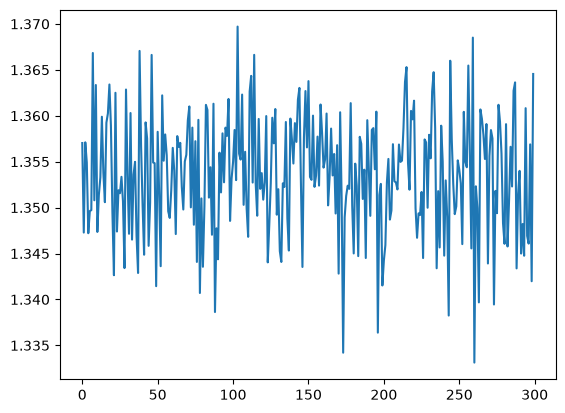

In [30]:
plt.plot(torch.tensor(lossi).view(1000, -1).mean(0))

In [31]:
def sample(nums):
  for i in range(nums):
    out = []
    context = [0] * block_size
    while True:
      contx  = torch.tensor([context])
      logits = model(contx)
      probs  = F.softmax(logits, dim=1)
      ix     = torch.multinomial(probs, num_samples=1, replacement=True).item()
      if ix == 0:
        break
      else:
        out.append(itos[ix])
      context = context[1:] + [ix]
    print(''.join(out))
    print("\n")

In [32]:
# to search whether the model is getting some words type from the data or it's just making them up
def search(x: str):
  count= 0
  cont = []
  for c in commits:
    if x.lower() in c.lower():
      cont.append(c)
      count+=1
  print(f'{count} matches found...')
  return cont if cont else None

In [75]:
for layer in model:
  if isinstance(layer, nn.BatchNorm1d):
    layer.training=False
sample(5)

gh-132591: distib.htypes on to Cissorifie (GH-154762)


gh-141101: Add ast all in builtoees.tipu_nstutiv} (#135359)


gh-137310: Reverify gager targing of it to sourceCodint commant (GH-148200)


gh-138736: add cleage pointer tomal events namis (#135312)


gh-140781: use `functoolAlna_deadata.raise_stack_inter`` (#135843)


